# 02 Exploratory analysis

Run notebook 01 first. This notebook reads the cleaned Tilak Nagar file, calculates summaries, and saves five charts.

We use ordinary variables and for loops. Each calculation has its own line. All results describe the surveyed residents, not every person in Tilak Nagar.

## 1. Import tools and read the clean file

In [1]:
# Pandas helps us work with tables.
import pandas as pd

# os helps us check where the data folder is.
import os

# Start by looking in the project folder.
project_folder = "."

# A notebook may start inside the notebooks folder instead.
if not os.path.exists("data/raw/survey_responses_raw.csv"):

    # Two dots mean the folder one level above this one.
    project_folder = ".."

# Matplotlib creates chart images.
import matplotlib.pyplot as plt

# Read the Tilak Nagar responses saved by notebook 01.
data = pd.read_csv(project_folder + "/data/processed/tilak_nagar_clean.csv")

# Create the chart folder if needed.
os.makedirs(project_folder + "/images", exist_ok=True)

# Show the number of respondents.
print("Tilak Nagar respondents:", len(data))

Tilak Nagar respondents: 26


## 2. Calculate overall satisfaction
`dropna()` removes missing ratings from the calculation. `mean()` calculates an average. `>= 4` selects ratings 4 and 5.

In [2]:
# Keep only valid overall ratings.
overall_ratings = data["overall_satisfaction"].dropna()

# Calculate the average overall rating.
overall_average = overall_ratings.mean()

# Select respondents who gave a rating of 4 or 5.
satisfied_ratings = overall_ratings[overall_ratings >= 4]

# Calculate the satisfied percentage using valid overall ratings.
overall_satisfied_percent = len(satisfied_ratings) / len(overall_ratings) * 100

# Show the results rounded to two decimal places.
print("Overall average:", round(overall_average, 2))
print("Overall satisfied percentage:", round(overall_satisfied_percent, 2))

Overall average: 3.81
Overall satisfied percentage: 53.85


## 3. List the services
The left side is the CSV column. The right side is the name shown to the reader.

In [3]:
# Match each rating column to a readable chart label.
services = {
    'water_supply': 'Water supply',
    'garbage_collection': 'Garbage collection',
    'public_cleanliness': 'Public cleanliness',
    'roads_footpaths': 'Roads and footpaths',
    'street_lighting': 'Street lighting',
    'drainage': 'Drainage',
    'public_toilets': 'Public toilets',
    'online_services': 'Online municipal services',
}

## 4. Calculate one row for each service
**Mean = sum of ratings / valid rating count.**

**Satisfied % = ratings 4 or 5 / valid rating count × 100.**

**Dissatisfied % = ratings 1 or 2 / valid rating count × 100.**

The loop repeats these same steps for each service. Missing ratings are excluded. A service with no valid ratings gets a blank result, not zero.

In [4]:
# Start an empty list for the summary rows.
summary_rows = []

# Work on one service column at a time.
for column in services:

    # Find the readable service name.
    service_name = services[column]

    # Keep only valid ratings for this service.
    ratings = data[column].dropna()

    # Count the valid ratings.
    valid_count = len(ratings)

    # Leave results blank until we know there are valid ratings.
    average = None
    satisfied_percent = None
    dissatisfied_percent = None

    # Only divide when there is at least one valid rating.
    if valid_count > 0:

        # Find the mean rating.
        average = round(ratings.mean(), 2)

        # Select the satisfied and dissatisfied ratings.
        satisfied = ratings[ratings >= 4]
        dissatisfied = ratings[ratings <= 2]

        # Work out the percentages one step at a time.
        satisfied_percent = len(satisfied) / valid_count * 100
        dissatisfied_percent = len(dissatisfied) / valid_count * 100

        # Round the percentages for the saved table.
        satisfied_percent = round(satisfied_percent, 2)
        dissatisfied_percent = round(dissatisfied_percent, 2)

    # Put this service's results into one row.
    row = [service_name, valid_count, average, satisfied_percent, dissatisfied_percent]

    # Add the row to the list.
    summary_rows.append(row)

## 5. Save the service summary
A list stores the rows. A DataFrame turns those rows into a table with named columns.

In [5]:
# Name the columns in the summary table.
summary_columns = [
    "service",
    "valid_ratings",
    "mean_rating",
    "satisfied_percent",
    "dissatisfied_percent",
]

# Turn our list of rows into a table.
summary = pd.DataFrame(summary_rows, columns=summary_columns)

# Save the table for the website.
summary.to_csv(project_folder + "/data/processed/service_summary.csv", index=False)

# Display the finished table.
summary

,service,valid_ratings,mean_rating,satisfied_percent,dissatisfied_percent
0,Water supply,26,3.88,69.23,7.69
1,Garbage collection,26,3.81,73.08,15.38
2,Public cleanliness,26,4.35,80.77,0.00
3,Roads and footpaths,26,3.73,57.69,7.69
4,Street lighting,26,3.85,80.77,15.38
5,Drainage,25,3.88,64.00,8.00
6,Public toilets,26,3.04,34.62,30.77
7,Online municipal services,12,3.42,33.33,8.33


## 6. Draw average service ratings
The chart compares means out of 5. The previous table shows each service’s valid count: online services has 12 and drainage has 25; other services have 26.

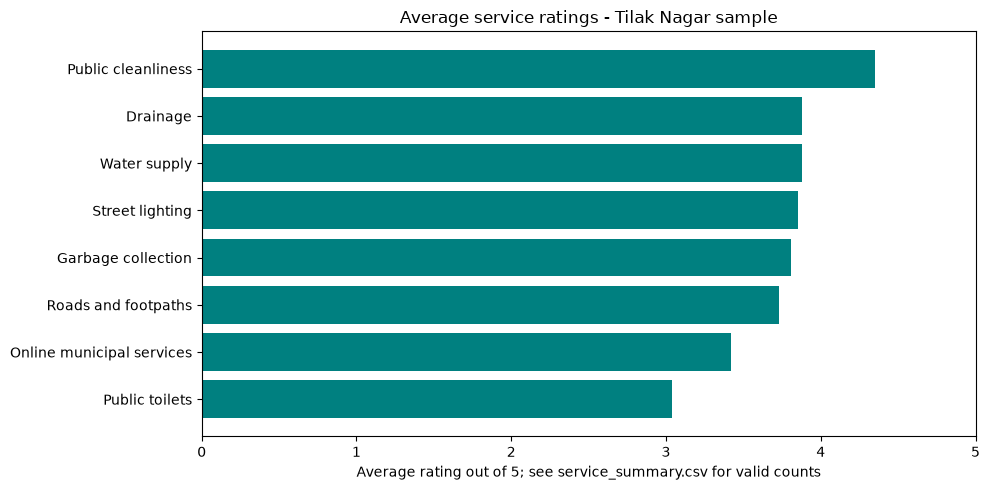

In [6]:
# Put the lower averages first.
chart_data = summary.sort_values("mean_rating")

# Create a figure with enough room for the service names.
plt.figure(figsize=(10, 5))

# Draw horizontal bars using service names and average ratings.
plt.barh(chart_data["service"], chart_data["mean_rating"], color="teal")

# Label the chart and use the full rating scale.
plt.title("Average service ratings - Tilak Nagar sample")
plt.xlabel("Average rating out of 5; see service_summary.csv for valid counts")
plt.xlim(0, 5)

# Fit the labels and save the image.
plt.tight_layout()
plt.savefig(project_folder + "/images/service_satisfaction.png", dpi=150)

# Display the chart and close it before the next chart.
plt.show()
plt.close()

## 7. Count the overall ratings
`value_counts()` counts each answer. `reindex()` includes all five ratings, even if nobody selected one. A zero **count** is valid; a missing **rating** is never changed to zero.

overall_satisfaction
1     0
2     1
3    11
4     6
5     8
Name: count, dtype: int64


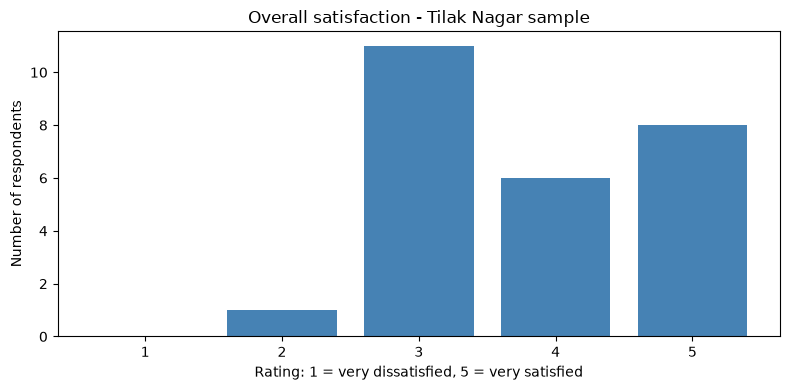

In [7]:
# Count each overall rating.
rating_counts = overall_ratings.value_counts()

# Show ratings 1 to 5 in order, including any zero counts.
rating_counts = rating_counts.reindex([1, 2, 3, 4, 5], fill_value=0)

# Display the counts.
print(rating_counts)

# Draw the count chart.
plt.figure(figsize=(8, 4))
plt.bar(rating_counts.index, rating_counts.values, color="steelblue")

# Add the title and axis labels.
plt.title("Overall satisfaction - Tilak Nagar sample")
plt.xlabel("Rating: 1 = very dissatisfied, 5 = very satisfied")
plt.ylabel("Number of respondents")
plt.xticks([1, 2, 3, 4, 5])

# Save and display the chart.
plt.tight_layout()
plt.savefig(project_folder + "/images/overall_satisfaction.png", dpi=150)
plt.show()
plt.close()

## 8. Count ratings for each service
This uses the same counting method in a loop. Rows are services; columns are ratings 1 to 5.

In [8]:
# Start an empty table for the rating counts.
distribution = pd.DataFrame()

# Count the five ratings for every service.
for column in services:

    # Count the ratings in this service column.
    counts = data[column].value_counts()

    # Include every rating category.
    counts = counts.reindex([1, 2, 3, 4, 5], fill_value=0)

    # Add these counts using the readable service name.
    distribution[services[column]] = counts

# Swap rows and columns so each row is one service.
distribution = distribution.T

# Display the counts.
distribution

water_supply,1,2,3,4,5
Water supply,0,2,6,11,7
Garbage collection,0,4,3,13,6
Public cleanliness,0,0,5,7,14
Roads and footpaths,0,2,9,9,6
Street lighting,1,3,1,15,6
Drainage,0,2,7,8,8
Public toilets,3,5,9,6,3
Online municipal services,0,1,7,2,2


## 9. Draw the service rating distributions
A stacked bar shows how the ratings are divided. Bar lengths differ because missing ratings are excluded.

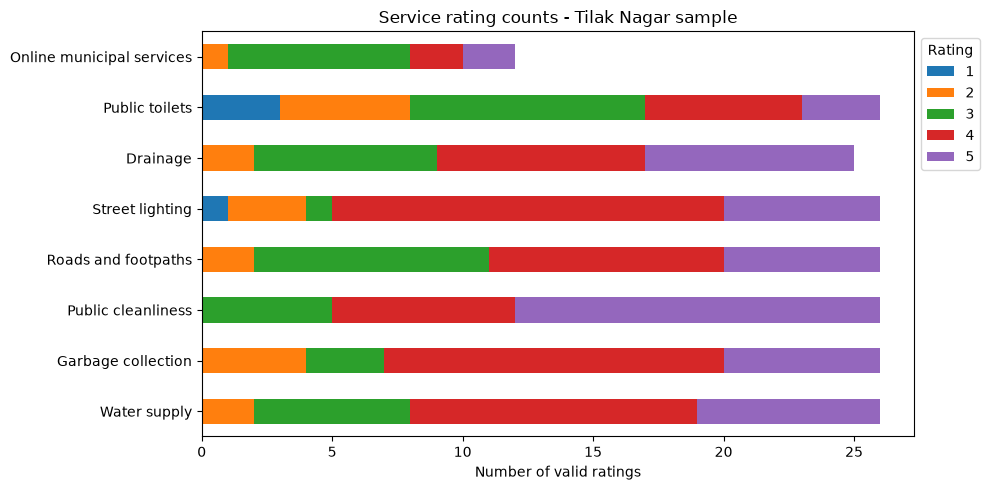

In [9]:
# Draw one stacked horizontal bar for each service.
distribution.plot(kind="barh", stacked=True, figsize=(10, 5))

# Add chart labels and put the legend outside the bars.
plt.title("Service rating counts - Tilak Nagar sample")
plt.xlabel("Number of valid ratings")
plt.ylabel("")
plt.legend(title="Rating", bbox_to_anchor=(1, 1))

# Save and display the chart.
plt.tight_layout()
plt.savefig(project_folder + "/images/rating_distribution.png", dpi=150)
plt.show()
plt.close()

## 10. Show online service non-use separately
A non-use answer is not dissatisfaction. The survey did not measure reasons for non-use.

Non-use: 14
Provided a rating: 12
Other or missing: 0


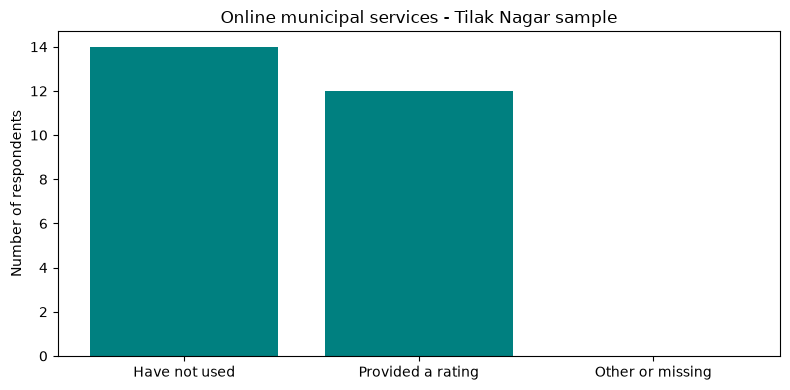

In [10]:
# Select respondents who explicitly said they had not used the service.
not_used_rows = data[data["online_services_response"] == "I have not used them"]

# Count non-use answers and valid ratings.
not_used_count = len(not_used_rows)
rated_count = data["online_services"].count()

# Count any remaining missing or not-applicable answers.
other_count = len(data) - not_used_count - rated_count

# Prepare labels and counts for the chart.
online_labels = ["Have not used", "Provided a rating", "Other or missing"]
online_counts = [not_used_count, rated_count, other_count]

# Print the exact counts.
print("Non-use:", not_used_count)
print("Provided a rating:", rated_count)
print("Other or missing:", other_count)

# Draw the chart and label it.
plt.figure(figsize=(8, 4))
plt.bar(online_labels, online_counts, color="teal")
plt.title("Online municipal services - Tilak Nagar sample")
plt.ylabel("Number of respondents")

# Save and display the chart.
plt.tight_layout()
plt.savefig(project_folder + "/images/online_service_use.png", dpi=150)
plt.show()
plt.close()

## 11. Save discussion priorities
We sort by dissatisfied percentage. This helps begin a discussion; it is not an official urgency or severity ranking.

In [11]:
# Put the highest dissatisfied percentage first.
priority = summary.sort_values("dissatisfied_percent", ascending=False)

# Save the priority table for the website.
priority.to_csv(project_folder + "/data/processed/issue_priority.csv", index=False)

# Display the priority table.
priority

,service,valid_ratings,mean_rating,satisfied_percent,dissatisfied_percent
6,Public toilets,26,3.04,34.62,30.77
1,Garbage collection,26,3.81,73.08,15.38
4,Street lighting,26,3.85,80.77,15.38
7,Online municipal services,12,3.42,33.33,8.33
5,Drainage,25,3.88,64.00,8.00
0,Water supply,26,3.88,69.23,7.69
3,Roads and footpaths,26,3.73,57.69,7.69
2,Public cleanliness,26,4.35,80.77,0.00


## 12. Draw the priority chart
The full percentage scale runs from 0 to 100. Use the valid count in the summary table when interpreting each percentage.

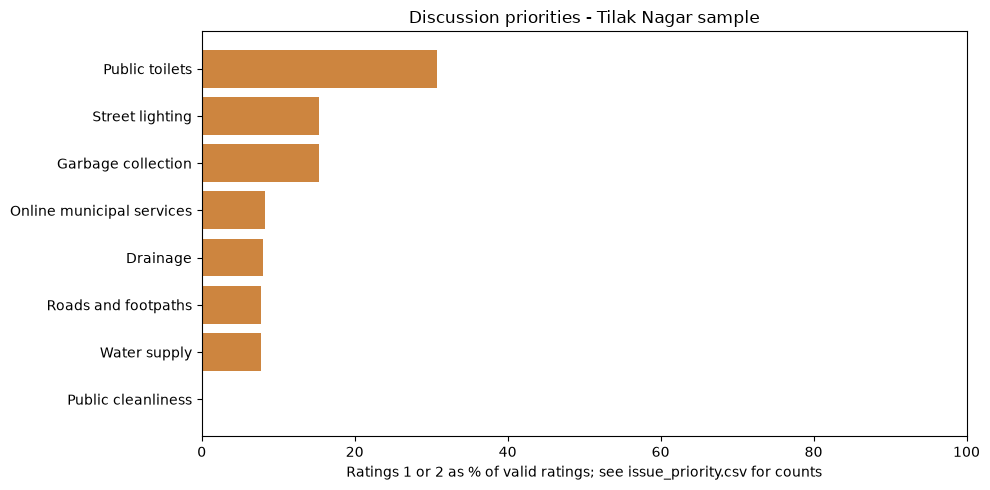

In [12]:
# Reverse the order so the largest horizontal bar appears at the top.
chart_data = priority.sort_values("dissatisfied_percent")

# Draw the dissatisfied percentages.
plt.figure(figsize=(10, 5))
plt.barh(chart_data["service"], chart_data["dissatisfied_percent"], color="peru")

# Add labels and the full percentage scale.
plt.title("Discussion priorities - Tilak Nagar sample")
plt.xlabel("Ratings 1 or 2 as % of valid ratings; see issue_priority.csv for counts")
plt.xlim(0, 100)

# Save and display the chart.
plt.tight_layout()
plt.savefig(project_folder + "/images/issue_priority.png", dpi=150)
plt.show()
plt.close()

## What to tell your teacher

“I used counts, averages, and percentages. I removed missing ratings before calculating. Then I used bar charts to compare services.”

For the supplied data: overall average **3.81/5**, overall satisfied **14/26 = 53.85%**, and public toilet dissatisfaction **8/26 = 30.77%**. Public toilets have the lowest mean, **3.04/5**. Public cleanliness has the highest mean, **4.35/5**. Online services have only **12** valid ratings, so their mean uses 12, not 26.

The charts and summaries are saved. Continue with notebook 03. If the raw data changes, update these written interpretations and the report after rerunning the notebooks.